<a href="https://colab.research.google.com/github/umachandola249/video_game-Sales_Analysis/blob/main/games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import os

path = kagglehub.dataset_download("rush4ratio/video-game-sales-with-ratings")

# List contents of the downloaded directory and find the CSV file
files = os.listdir(path)

csv_file = None
for f in files:
    if f.endswith('.csv'):
        csv_file = f
        break

if csv_file:
    full_csv_path = os.path.join(path, csv_file)
    df = pd.read_csv(full_csv_path)
    print(df.head())
else:
    print(f"No CSV file found in the downloaded directory: {path}")
    print(f"Files found: {files}")

Using Colab cache for faster access to the 'video-game-sales-with-ratings' dataset.
                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24           NaN   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00     

#check for missing value

In [ ]:
print ( df.isnull().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64


#check for duplicate rows

In [ ]:
print ( df.duplicated().sum())
df= df.drop_duplicates()

0


#summary statistics of numerical data

In [ ]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [ ]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [ ]:
from google.colab import files
df.to_csv('df_clean.csv', index=False)
files.download('df_clean.csv')
print( 'successful in downloading and saving cleaned dataset')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

successful in downloading and saving cleaned dataset


Using Colab cache for faster access to the 'video-game-sales-with-ratings' dataset.


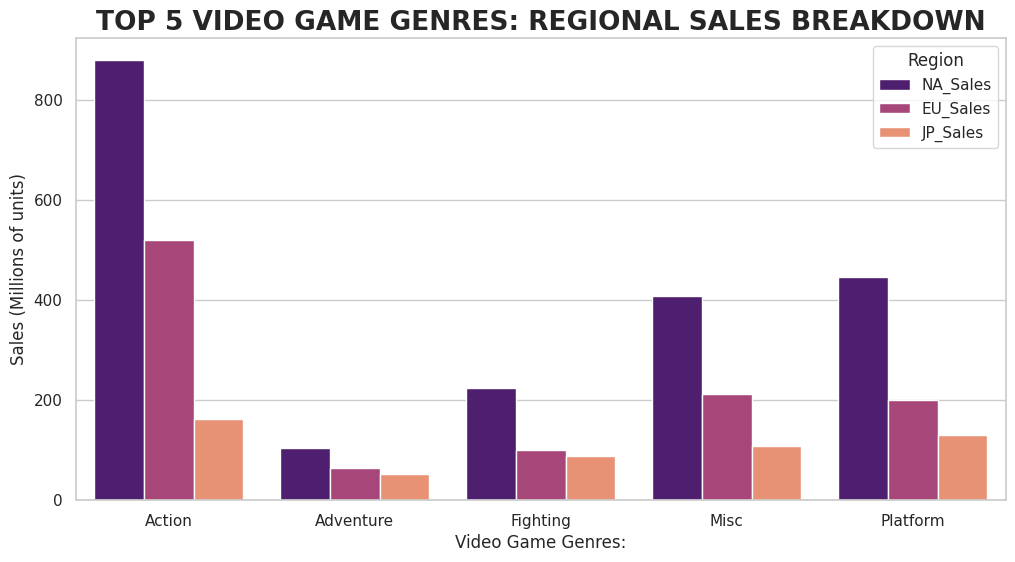

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
import os

# Re-define df here to ensure it's available in this cell's scope
# if preceding cells haven't been run or the kernel was reset.
path = kagglehub.dataset_download("rush4ratio/video-game-sales-with-ratings")
files = os.listdir(path)
csv_file = None
for f in files:
    if f.endswith('.csv'):
        csv_file = f
        break

if csv_file:
    full_csv_path = os.path.join(path, csv_file)
    df = pd.read_csv(full_csv_path)
    df = df.drop_duplicates() # Apply cleaning from cell PZoMDKszmSyH
else:
    print("Error: No CSV file found for 'video-game-sales-with-ratings' dataset. Cannot proceed with plotting.")
    # Create an empty DataFrame with expected columns to prevent further errors if CSV not found
    df = pd.DataFrame(columns=['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales'])

sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))

# Define regional_trends by grouping df by Genre and summing regional sales
regional_trends = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum().reset_index()
melted_df = pd.melt(regional_trends.head(5), id_vars=['Genre'], value_vars=['NA_Sales', 'EU_Sales', 'JP_Sales'], var_name='Region', value_name='Sales_Millions')
sns.barplot(data=melted_df ,x='Genre', y='Sales_Millions', hue='Region', palette='magma')
plt.title('TOP 5 VIDEO GAME GENRES: REGIONAL SALES BREAKDOWN', fontsize=19, fontweight='bold')
plt.xlabel('Video Game Genres:', fontsize=12)
plt.ylabel('Sales (Millions of units)', fontsize=12)
plt.legend(title='Region', loc='upper right')
plt.show()

#ANALYZE WITH SQL

In [ ]:
!pip install pandasql
from pandasql import sqldf
pysqldf = lambda q: sqldf(q , globals())

#GLOBAL SALES OF DIFFERENT GENRE

In [ ]:
query1 = ''' SELECT Genre, SUM(Global_Sales) as Total_Global_Sales
FROM df
GROUP BY Genre
ORDER BY Total_Global_Sales DESC
'''
pysqldf(query1)

,Genre,Total_Global_Sales
0,Action,1745.27
1,Sports,1332.00
2,Shooter,1052.94
3,Role-Playing,934.40
4,Platform,828.08
5,Misc,803.18
6,Racing,728.90
7,Fighting,447.48
8,Simulation,390.42
9,Puzzle,243.02


In [ ]:
print(df.columns)

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')


# TOTAL SALES ON THE YEAR OF RELEASE OF GAME

In [ ]:
query2='''SELECT Year_of_Release , SUM(Global_Sales) as Total_Global_Sales
FROM df
GROUP BY Year_of_Release
ORDER BY Total_Global_Sales DESC
'''
pysqldf(query2)

,Year_of_Release,Total_Global_Sales
0,2008.0,671.79
1,2009.0,658.88
2,2007.0,605.37
3,2010.0,590.59
4,2006.0,518.22
5,2011.0,507.79
6,2005.0,458.31
7,2004.0,419.05
8,2002.0,395.51
9,2013.0,361.24


#TOTAL GLOBAL SALES BY DIFFERENT PLATFORM

In [ ]:
query3='''SELECT Platform , SUM(Global_Sales) as Total_Global_Sales
FROM df
GROUP BY Platform
ORDER BY Total_Global_Sales DESC
'''
pysqldf(query3)

,Platform,Total_Global_Sales
0,PS2,1255.64
1,X360,971.63
2,PS3,939.43
3,Wii,908.13
4,DS,807.10
5,PS,730.68
6,GBA,318.50
7,PS4,314.23
8,PSP,294.30
9,PC,260.30


#TOTAL GLOBAL SALES BY DIFFERENT PUBLISHER

In [ ]:
query4= ''' SELECT Publisher , SUM(Global_Sales)as Total_Global_Sales
FROM df
GROUP BY Publisher
ORDER BY Total_Global_Sales DESC
'''
pysqldf(query4)

,Publisher,Total_Global_Sales
0,Nintendo,1788.81
1,Electronic Arts,1116.96
2,Activision,731.16
3,Sony Computer Entertainment,606.48
4,Ubisoft,471.61
...,...,...
577,Genterprise,0.01
578,EON Digital Entertainment,0.01
579,Commseed,0.01
580,Boost On,0.01
